### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

By Maurice Baxter, Ellinor Myrén and Märta Petersson

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

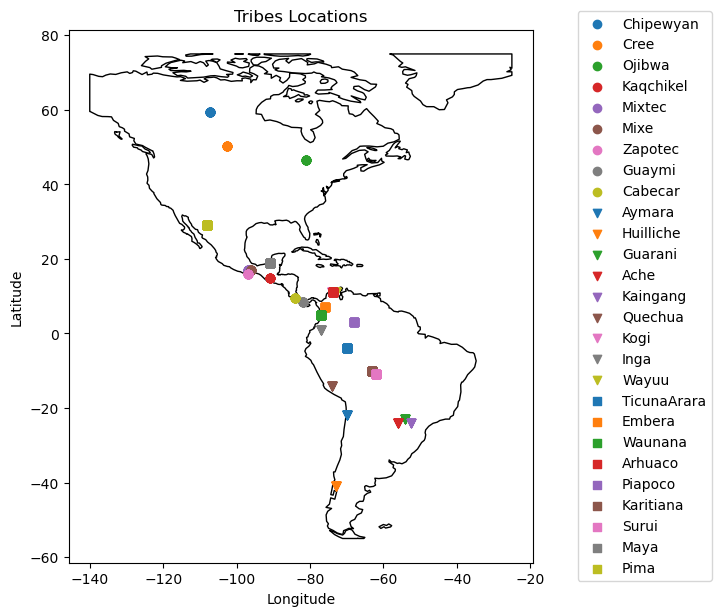

In [87]:
# import necessary packages
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude)) # creates geodataframe as df with an additional appended consisting of pairs (longitude, latitude)

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land')) # load world map layer from Natural Earth dataset via geodatasets and read it in as a geodataframe

fig, ax = plt.subplots(figsize=(8.0, 6.5)) # create matplotlib Figure and Axes for plotting with specific dimensions

plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92) # adjust subplot margins to on right, bottom and top to make space for legend 

world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black') # the list [-140, -55, -25, 75] corresponds to [min_lon, min_lat, max_lon, max_lat]. Hence world.clip clips the world geodataframe to this latitudinal and longitudinal bounds. Then plot the cliiped word onto ax with black outline and white background. 

# prepare marker shapes and colours for plotting tribes
marker_list = ['o', 'v', 's'] # 3 possible marker shapes

colors_list = [f'C{i}' for i in range(9)] # 9 category colours accessed as C0 through C8


for i, tribe in enumerate(gdf['Pop'].unique()): # loops over ecah unique tribe in the 'Pop' column of gdf
    members_tribe = gdf[gdf['Pop'] == tribe] # define dataframe corresponding to all rows for current tribe of the ith iteration
    ax.scatter(members_tribe['long'], members_tribe['lat'], # use longitude and latitude of current tribe as coordinates (constant across every row given a tribe)
               marker=marker_list[i//9], # assign 'o' marker to first 9 (indices 0-8) tribes, ''v' marker to following 9 tribes (indices 9-17) and 's' to final 9 tribes (indices 18-26)
               color=colors_list[i%9], label=tribe) # assign colours C0 through C8 to tribes 0 through 8 and repeat similarly for tribes 9 through 17 and 8 through 26. 
# In this way no two tribes are both assigned the same colour and the same marker. 

# adds legend onto ax
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))

# add Title to plot
ax.set_title('Tribes Locations')

# add x and y axis labels
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# show the fig
plt.show()

Explain how the above code works
- are comment above enough or put brief text here? 

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [88]:
import numpy as np
X = df.drop(list(df)[0:8], axis=1)
y = df[['lat', 'long']]

X.head()

,L1.125,L1.130,L1.135,L1.140,L1.142,L1.145,L1.150,L1.150.940397350993,L1.152,L1.155,L1.160,L1.165,L2.260,L2.264,L2.268,L2.280,L2.284,L2.288,L2.288.18,L2.292,L2.293,L2.296,L3.126,L3.130,L3.134,L3.138,L3.139.830927835052,L3.142,L3.146,L3.150,L4.152,L4.156,L4.160,L4.164,L4.167.487858719647,L4.168,L4.172,L4.176,L4.180,L4.184,...,L673.251,L673.253.468085106383,L673.255,L673.259,L673.263,L674.243,L674.247,L674.251,L674.255,L674.257.845814977974,L674.259,L674.263,L674.267,L675.169,L675.173,L675.174.663793103448,L675.177,L675.181,L676.171,L676.181,L676.186,L676.191,L676.193.653276955603,L676.196,L676.201,L676.206,L676.211,L677.243,L677.251,L677.255,L677.255.553287981859,L677.259,L677.263,L677.267,L678.202,L678.206,L678.209.848101265823,L678.210,L678.214,L678.218
Chipewyan29,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
Chipewyan31,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
Chipewyan33,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
Chipewyan35,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
Chipewyan37,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0


In [3]:
# define variables for equation
A = X.T @ X
B = X.T @ y

Using 'np.linalg.solve(A, B)' to obtain the values of $\beta$ returns the error *Singlar matrix*. That is, the matrix $A = X^T X$ is singular. Given that the dimensions of $X$ are $N \times p$, $A = X^T X$ has dimensions $p \times p$. Hence by the rank-nullity theorem, 
$$ A \quad \text{is invertible} \Leftrightarrow \text{rank} \: A = p $$
But we know from linear algebra
$$ \text{rank} \: A = \text{rank} \:  X < p$$
Hence $A$ is not invertible (i.e. is singular). 


**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [269]:
beta_vector1 = np.linalg.lstsq(A, B)
beta_vector1

(array([[ 0.04545534, -0.04005781],
        [ 0.01192706, -0.01940898],
        [-0.01172507,  0.01111306],
        ...,
        [-0.13578198, -0.21729626],
        [ 0.08227136, -0.10210421],
        [-0.08275851,  0.01813644]], shape=(5709, 2)),
 array([], dtype=float64),
 np.int32(494),
 array([1.22595906e+05, 3.75526477e+03, 3.18897815e+03, ...,
        1.09923146e-11, 3.18641437e-12, 4.33094166e-13], shape=(5709,)))

The function 'numpy.linalg.solve' attemps to exactly solve the matrix equation. This requires a square and nonsingular matrix $X^T X$. By construction $X^T X$ is indeed square- but as was shown above it is also singular. Hence no exact solution exists.

Alternatively, the function 'numpy.linalg.lstsq' does not solve the normal equation explicity. Instead, it uses SVD to compute a least-squares solution that minimises $||\textbf{X}\beta- y||_2$. This works even when $\textbf{X}$ is tall ($N \geq p$) but without full rank (or alternatively $\textbf{X}$ is wide $p> N$ and so the system is undetermined). 

The computational complexity of performing SVD on such a larger matrix is the reason that this function takes > 1 minute to run. 

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [89]:
from sklearn.linear_model import LinearRegression

predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df[['long']]
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)

# get the coefficients
beta_vector2 = lr.coef_
beta_vector2


array([[-0.03940988, -0.0245272 ,  0.01089763, ...,  0.04804479,
        -0.08985062,  0.01903025]])

Firstly note that the linear regression model must either return no intercept or a non-zero intercept. It is practically useful that in either case the intercept (which is the predicted longitude (or latitude)) be a value which can be meaningfully interpreted. Recentering of the predictors allows for this by enforcing that the intercept be the predicted value when all predictors are equal to their respective means. Otherwise the intercept is the predicted value for where all predictors are equal to 0 (i.e. a sample who has none of the listed genetic markers). This is a practically less interesting case to study.  

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

The main goal of PCA is to reduce the number of features in a dataset while preserving, via these features, as much as possible of the original variance. The motivation behind PCA is that, in general, not all features come equal in their usefulness to prediction: less useful features may be condensed and more useful features highlighted. PCA creates new features that provide the best possible approximation of the important features and hence are able to explain a large (enough) proportion of variance in the data. 

More specifically, PCA is the orthogonal linear transformation that transforms a set of data to a basis where the vector on which lies the greatest possible variance by a projection of the data is precisely the first basis vector and so on such that the nth greatest variance lies on the nth basis vector.  This first basis vector is called the first principal component and points in the direction in which the variance of the data is maximal. This vector conveniently corresponds to the eigenvector associated with the largest eigenvalue of the covaraince matrix. The desired number of principal components can be selected as that which allows the threshold variance to be captured (e.g. 95%). Given the selected components, the dataset can be projected on them to produce the transformed dataset (of lower dimension in particular). 

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

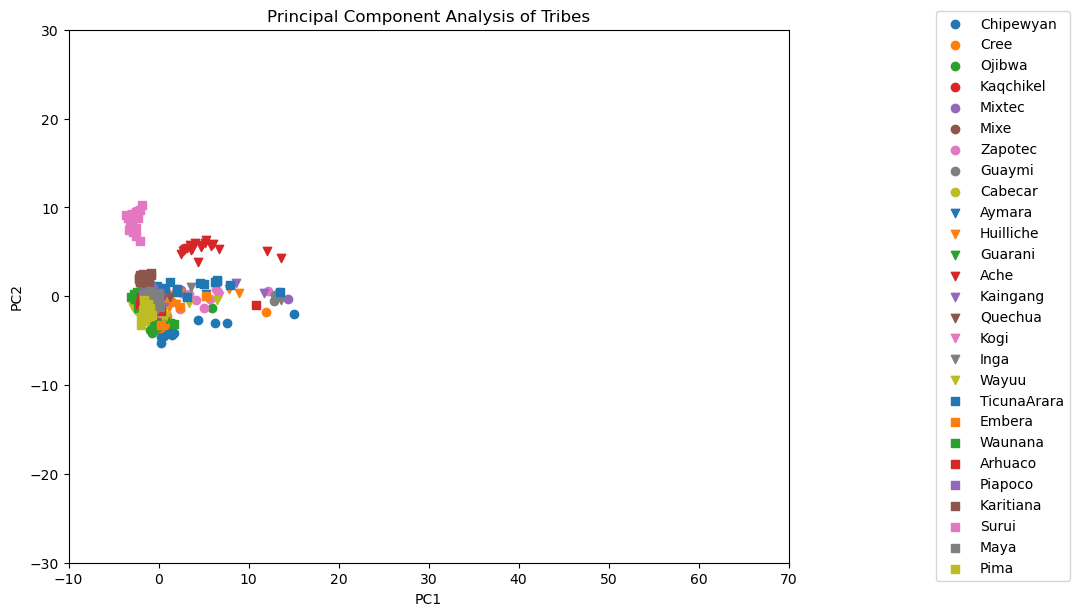

In [90]:
from sklearn.decomposition import PCA

pca_not_standardised = PCA(n_components=2)
pca_not_standardised.fit(X)
X_pca_not_standardised = pca_not_standardised.transform(X)

# Create a new DataFrame with 'Pop' as the first column and the two PCA columns
new_df = pd.DataFrame({
    'Pop': df['Pop'],              # First column: 'Pop' from df
    'PC1': X_pca_not_standardised[:, 0],         # Second column: First principal component
    'PC2': X_pca_not_standardised[:, 1]          # Third column: Second principal component
})

# Plotting
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(new_df['Pop'].unique()):
    members_tribe = new_df[new_df['Pop'] == tribe]
    ax.scatter(members_tribe['PC1'], members_tribe['PC2'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Principal Component Analysis of Tribes')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

plt.xlim(-10, 70) 
plt.ylim(-30, 30) 


plt.show()

The above plots Principal Component 1 against Principal Component 2 using the non-standardised set of features (genetic markers). Each individual point represents a Tribe Member while the family of (shape, colour) represents all the members of a given tribe. 

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

In [7]:
# normalised version of the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
X_std

array([[-0.04503773, -0.04503773, -0.04503773, ...,  0.35395584,
        -0.11989044, -0.06375767],
       [-0.04503773, -0.04503773, -0.04503773, ..., -2.82521117,
        -0.11989044, -0.06375767],
       [-0.04503773, -0.04503773, -0.04503773, ..., -2.82521117,
        -0.11989044, -0.06375767],
       ...,
       [-0.04503773, -0.04503773, -0.04503773, ...,  0.35395584,
        -0.11989044, -0.06375767],
       [-0.04503773, -0.04503773, -0.04503773, ...,  0.35395584,
        -0.11989044, -0.06375767],
       [-0.04503773, -0.04503773, -0.04503773, ...,  0.35395584,
        -0.11989044, -0.06375767]], shape=(494, 5709))

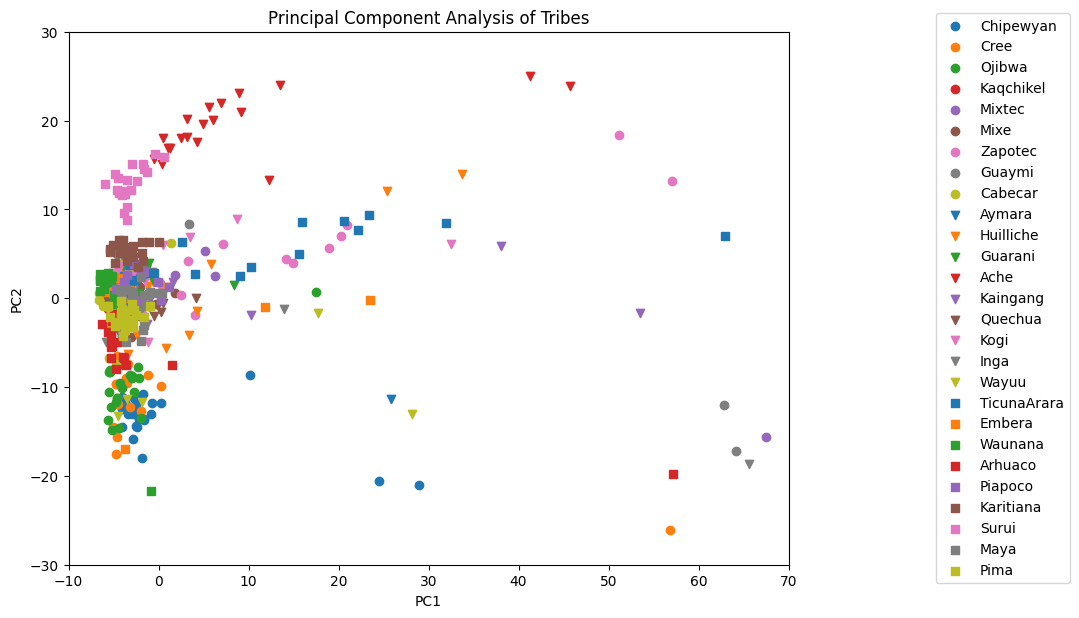

In [72]:
pca_standardised = PCA(n_components=2)
pca_standardised.fit(X_std)
X_pca_standardised = pca_standardised.transform(X_std)

# Create a new DataFrame with 'Pop' as the first column and the two PCA columns
new_df = pd.DataFrame({
    'Pop': df['Pop'],              # First column: 'Pop' from df
    'PC1': X_pca_standardised[:, 0],         # Second column: First principal component
    'PC2': X_pca_standardised[:, 1]          # Third column: Second principal component
})

# Plotting
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(new_df['Pop'].unique()):
    members_tribe = new_df[new_df['Pop'] == tribe]
    ax.scatter(members_tribe['PC1'], members_tribe['PC2'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Principal Component Analysis of Tribes')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

plt.xlim(-10, 70) 
plt.ylim(-30, 30) 

plt.show()

The above plots Principal Component 1 against Principal Component 2 using the **standardised** set of features (genetic markers). Each individual point represents a Tribe Member while the family of (shape, colour) represents all the members of a given tribe. 

The primary difference between this plot and the non-standardised plot is a general change in the magnitude of data points (e.g. maximum has changed from approximately 15 to 70). The other evident visual change is a decreased clustering of points around the horizontal 0 line. In particular, the second plot represents two components that are relatively evenly spread from in $[-10, 70] \times [-30, 30]$ while the first plot represents two components spread over $[-3, 15] \times [-6, 10]$. 

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

Each feature takes on a value of 0 or 1. Hence the mean of every feature ( = a genetic marker) by construction ranges between 0 and 1. The same applies to the variances. There is hence, a priori, not much reason to standardise the data points for the dataset considered. In practice, as we can see comparing the two plots, doing so serves mostly to uniformly change the scale of the data. 

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

In [56]:
print('Percentage of variance captured by first two principal components (after standardisation) =', np.round(pca_standardised.explained_variance_ratio_*100, 2))


Percentage of variance captured by first two principal components (after standardisation) = [2.37 1.03]


Hence the percentage of variance captured by the first principal component is $2.37$% and by the second component is $1.03$%. We consider the following plot to determine how many principal components we would keep in order to represent the genetic markers using a minimal number of principal components:

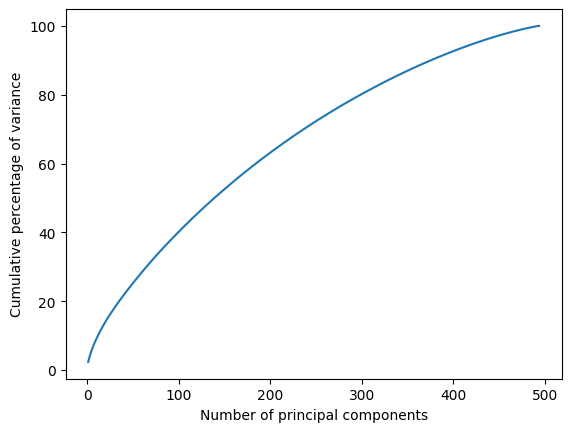

number of principal components for which for cumulative percentage of variance is 1: []


In [71]:
cumulative_percentage_of_variance = []

# pca for maximum number of possible principal components = 494
pca = PCA(n_components=X.shape[0])
pca.fit(X_std)
X_pca= pca.transform(X_std)

# define list containing cumulative percentage of variance for every possible number of principal components from 1 to 494
cumulative_percentage_of_variance = [100*np.sum([pca.explained_variance_ratio_[k] for k in range(0, j)]) for j in range(1, X.shape[0]+1)]

plt.plot(range(1, X.shape[0]+1, 1), cumulative_percentage_of_variance)

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative percentage of variance")
plt.show()

print('number of principal components for which for cumulative percentage of variance is 1:', np.array([k for k in range(1, X.shape[0], 1) if cumulative_percentage_of_variance[k] == 1])+1)

At n_components = 493 we have $\sum_{i=1}^{n_components} \text{percentage of variance captured by the ith component} = 1 $ and hence all variance in the data set in captured by PCA on n_components = 493. Although this value of n_components is the minimum, n_components = 494 = number of samples will always produce a cumulative percentage of variance of 1. 

To decide on many principal components to keep for a 'minimal representation' requires that we choose a target cumulative variance threshold. The necessary number of principal components for a variety of thresholds is given below: 

In [212]:

cumulative = np.cumsum(pca.explained_variance_ratio_)

def k_for_threshold(prop):
    """th is a proportion: 0.90, 0.95, 0.99, 1"""
    return int(np.argmax(cumulative >= prop)) + 1

k90 = k_for_threshold(0.90)
k95 = k_for_threshold(0.95)
k99 = k_for_threshold(0.99)
k100 = k_for_threshold(0.99999999999999)

print(f"k for 90%: {k90},     95%: {k95},     99%: {k99},     100%: {k100}")


k for 90%: 376,     95%: 425,     99%: 476,     100%: 493


## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

In [91]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Extracting just the genetic marker columns:
markers = df.iloc[:, 8:]

# Regression for latitude using a pipline
pipe_lat = make_pipeline(StandardScaler(), PCA(n_components=250), LinearRegression())
pipe_lat.fit(markers, latitude)
pred_lat = pipe_lat.predict(markers)

# Regression for longitude using a pipline
pipe_long = make_pipeline(StandardScaler(), PCA(n_components=250), LinearRegression())
pipe_long.fit(markers, longitude)
pred_long = pipe_long.predict(markers)


# New GeoDataFrame for predicted values:
gdf_pred = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(pred_long, pred_lat))


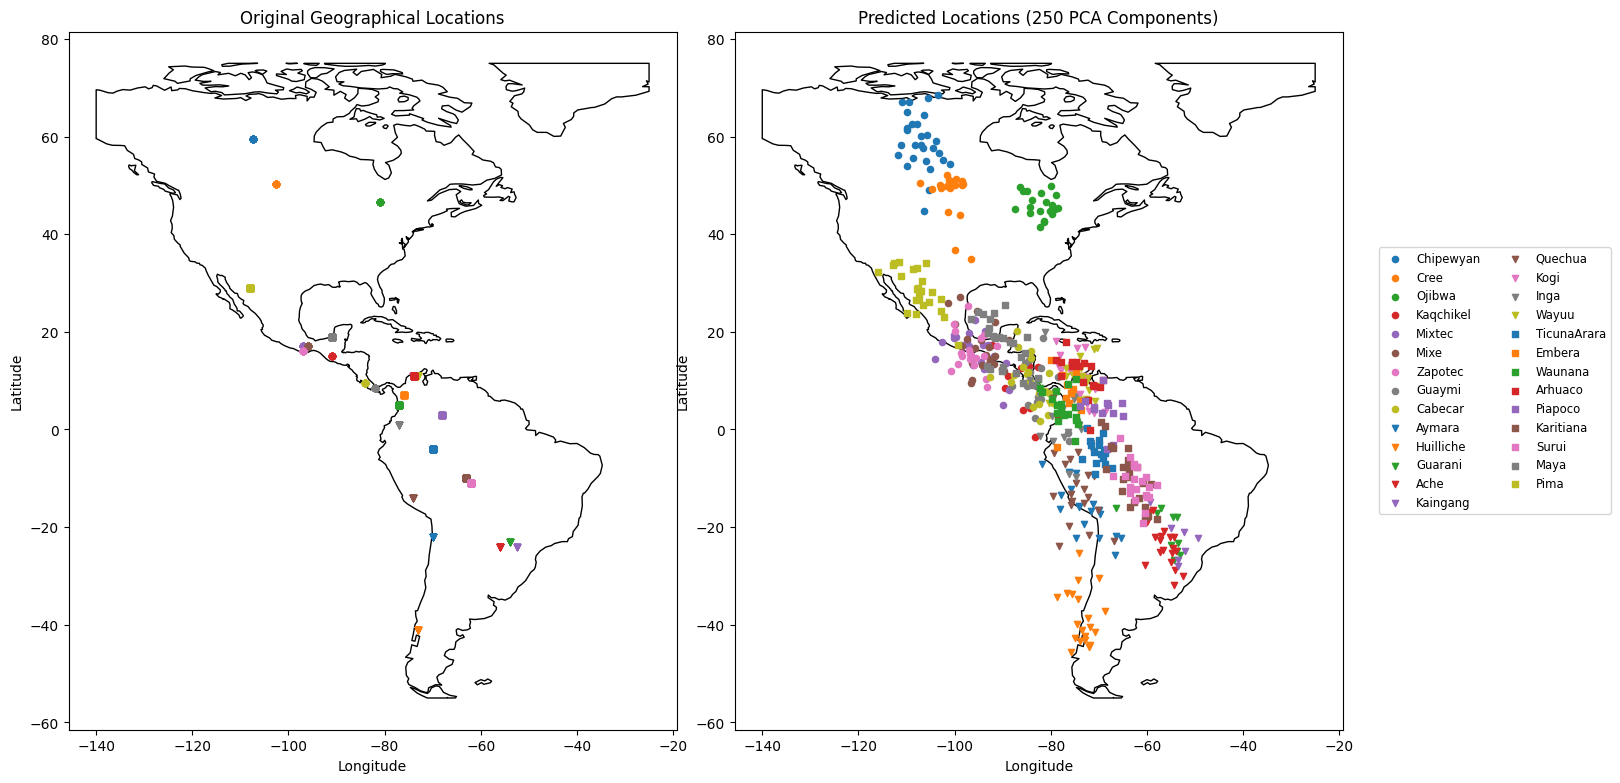

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Define shared plotting parameters
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
extent = [-140, -55, -25, 75]
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

# Loop through both axes to plot the background map
for ax in [ax1, ax2]:
    world.clip(extent).plot(ax=ax, color='white', edgecolor='black')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# --- Plot 1: ORIGINAL ---
for i, tribe in enumerate(gdf['Pop'].unique()):
    members = gdf[gdf['Pop'] == tribe]
    ax1.scatter(members['long'], members['lat'], 
                marker=marker_list[i//9], color=colors_list[i%9], s=20)
ax1.set_title('Original Geographical Locations')

# --- Plot 2: PREDICTED  ---
for i, tribe in enumerate(gdf_pred['Pop'].unique()):
    members = gdf_pred[gdf_pred['Pop'] == tribe]
    # Use the predicted columns from Ex 4 (columns long and lat still contain the true coordinate values)
    ax2.scatter(pred_long[gdf_pred['Pop'] == tribe], 
                pred_lat[gdf_pred['Pop'] == tribe], 
                marker=marker_list[i//9], color=colors_list[i%9], s=20)
ax2.set_title('Predicted Locations (250 PCA Components)')

# Add one shared legend to the right of the second plot
ax2.legend(gdf['Pop'].unique(), loc='center left', bbox_to_anchor=(1.05, 0.5), ncol=2, fontsize='small')

plt.tight_layout()
plt.show()


**4 (a)** 

In the figure above, the map with the true coordinates for the tribes are plotted next to a map of the predicted coordinates for each tribe member. The predicted coordinates correspond very well with the true coordinates, which indicates that genetic markers work well for predicting geographic origin.

However, the predicitons are made on the same data as the model was trained on. To ensure that the model truly represents the correlation between genetic markers and geographical location, and has not not simply memorized the data it was trained on, it must be evaluated on unseen data. It should also be noted that the dataset contains 494 samples, and that during PCA 250 components were kept. The number of observations is only double the amount of features, creating a high-dimensional model, which makes the risk of memorizing very high. In conclusion, the map shows the possibility to predict geographical location based on genetic markers too optimistically.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [92]:
from sklearn.metrics.pairwise import haversine_distances

def km_error(true_coords, pred_coords):

    # Must convert degrees to radians:
    true_coords = np.radians(true_coords)
    pred_coords = np.radians(pred_coords)

    # Compute pairwise haversine distances:
    dist_matrix = haversine_distances(true_coords, pred_coords)

    # We only need the diagonal (the distance for each pair):
    distances = np.diag(dist_matrix)

    # Convert back to kilometers
    earth_radius_km = 6371
    distances_km = distances * earth_radius_km

    # Mean error
    mean_distance_km = distances_km.mean()
    
    return mean_distance_km

true_coords = np.column_stack((latitude.values, longitude.values))
pred_coords = np.column_stack((pred_lat, pred_long))

print("Mean distance error (km):", km_error(true_coords, pred_coords))


Mean distance error (km): 508.7576955385498


**4 (b)**

The mean distance error in km is calculated and printed above. It is the mean of the error between the predicted coordinate and the true coordinate for each tribe member.

For comparison: The distance from the northernmost point to the southernmost point of the american continent is about 15000 km. The distance between the westernmost point and eastermost point s about 16000 km. The error is roughly 3% of the distances.

## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

Cross-validation is a method used to evaluate how well a predictive model generalizes to new data. The idea is to split the dataset into training and test parts, train the model on the training data and evaluate it on the test data and repeat the process multiple times. Then we take the average of the prediction errors from the different splits to get a more reliable estimate of the model’s performance.

Cross-validation is useful when building a predictive model becuase it's good for selecting model parameters, like the number of predictors in linear regression or the number of principal components in PCR. Then we can choose the value that minimizes the average prediction error instead of using a single train-test split, which could give misleading results if the split is 'lucky' or 'unlucky'. By averaging the error over several splits, we can evaluate the model’s performance more reliably and ensure that it generalizes well to new unseen data.

When the samples are not IID, we can use for example GroupKFold. It works well when observations belong to groups and we want to ensure that the same group does not appear in both the training and test set because that could make the model learn how that group usually works and the model will look better than it is. For ordered data TimeSeriesSplit should be used so that future observations are not used to predict past observations.

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

In this dataset individuals are from different countries and belong to different tribes. Individuals from the same tribe probably have similar genetic markers. This means that the samples are not fully independent. If both the training and testing set contains individuals from the same tribe, the model could indirectly learn how that specific tribe usually scores and the prediction error would be lower than the model actually performs.

A group-based cross-validation strategy would be more reliable. A good choice from the sklearn iterators is GroupKFold, where the groups correspond to the tribes. This ensures that individuals from the same tribe are always in the same fold, so the model is tested on populations that were not seen during training. This gives a more realistic estimate of how well the model can generalize to new individuals from unseen populations. In the instructions under Exercise 5 it says to do ten-fold cross validation so therefore we will still do KFold instead of GroupKFold in the next exercises.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [75]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer

#make the function from 4(b) into a scorer to use it in the cross validate function
km_scorer = make_scorer(km_error, greater_is_better=False)
X = markers
y = true_coords
pcr = make_pipeline(StandardScaler(), PCA(n_components=4), LinearRegression())
cv = KFold(n_splits=10, shuffle=True, random_state=42)

#do a ten-fold cross-validation
scores = cross_validate(pcr, X, y, cv=cv, scoring=km_scorer, return_train_score=True)
test_error = (-scores['test_score'].mean())

print(f"Test error for 4 principal components using mean distance error: {test_error:.2f} km")

Test error for 4 principal components using mean distance error: 2031.61 km


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

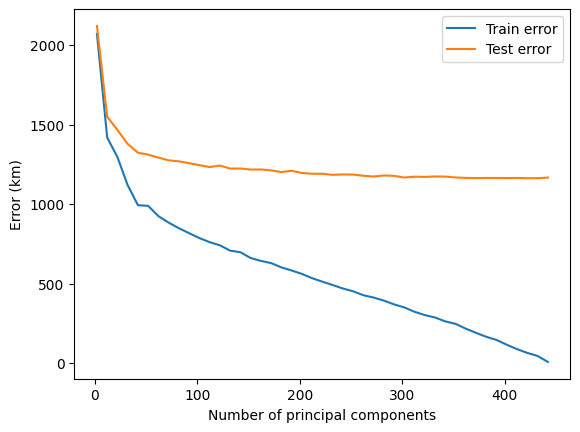

In [64]:
train_errors = []
test_errors = []
cv = KFold(n_splits=10, shuffle=True, random_state=42)

#calculate the training error and test error for principal components between 2 and 440
for n in range(2, 440, 10):
    pcr = make_pipeline(StandardScaler(), PCA(n_components=n), LinearRegression())
    scores = cross_validate(pcr, X, y, cv=cv, scoring=km_scorer, return_train_score=True)
    train_errors.append(-scores['train_score'].mean())
    test_errors.append(-scores['test_score'].mean())

#plot the training and test error in the same plot
plt.plot(range(2, 440, 10), train_errors, label="Train error")
plt.plot(range(2, 440, 10), test_errors, label="Test error")
plt.xlabel("Number of principal components")
plt.ylabel("Error (km)")
plt.legend()
plt.show()


**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

In [78]:
print(f"Prediction error: {test_errors[10]:.2f} using mean distance error (km) with 102 principal components") #n=10 corresponds to 102 principal components
print(f"Training error: {train_errors[10]:.2f} using mean distance error (km) with 102 principal components")
print(f"For comparison, Prediction error: {test_errors[43]:.2f} using mean distance error (km) with 432 principal components")

Prediction error: 1241.67 using mean distance error (km) with 102 principal components
Training error: 783.61 using mean distance error (km) with 102 principal components
For comparison, Prediction error: 1162.44 using mean distance error (km) with 432 principal components


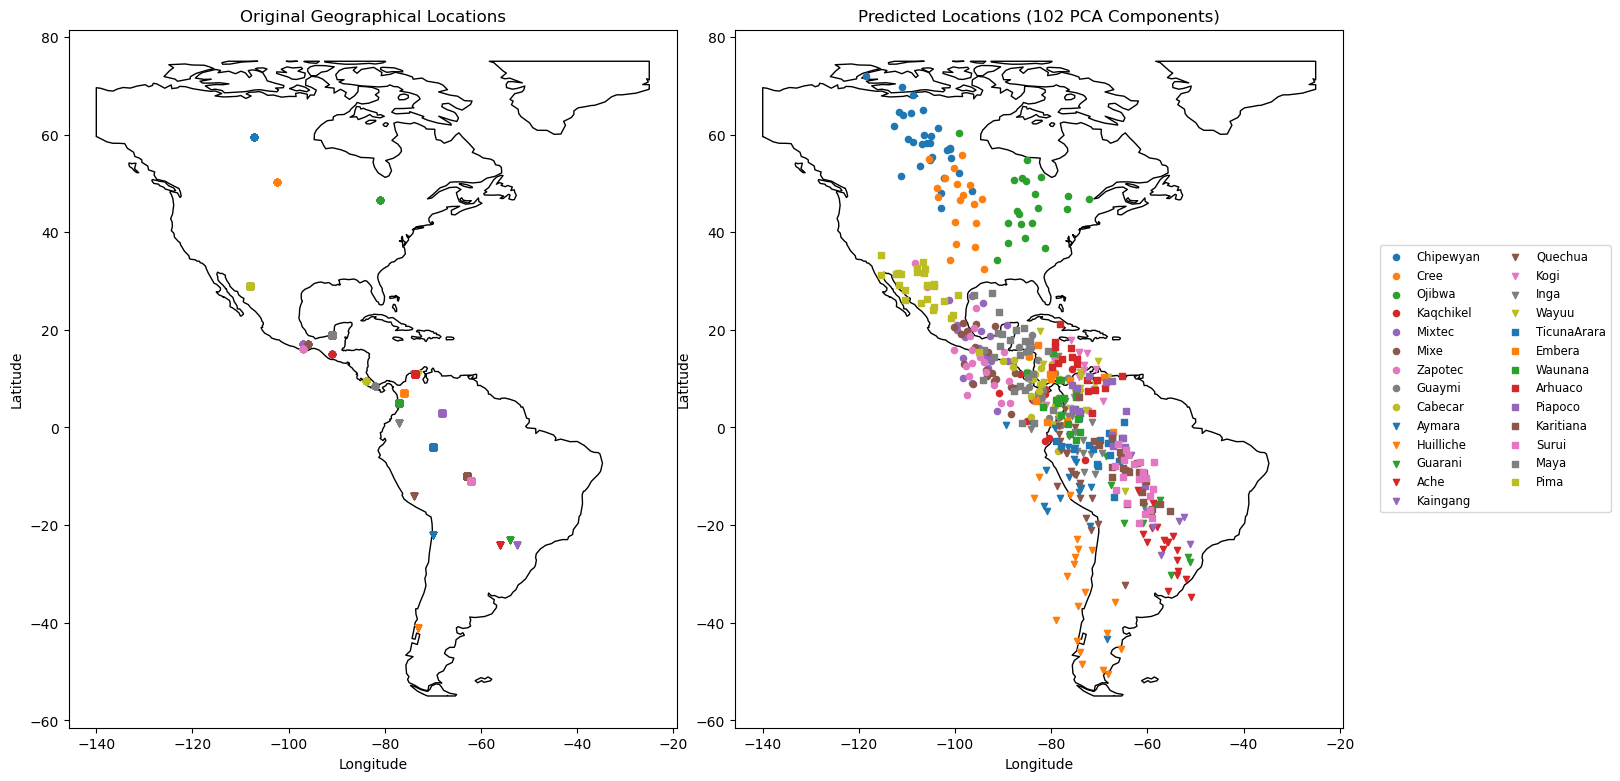

In [96]:
# Regression for latitude using a pipline
pipe_lat = make_pipeline(StandardScaler(), PCA(n_components=102), LinearRegression())
pipe_lat.fit(markers, latitude)
pred_lat = pipe_lat.predict(markers)

# Regression for longitude using a pipline
pipe_long = make_pipeline(StandardScaler(), PCA(n_components=102), LinearRegression())
pipe_long.fit(markers, longitude)
pred_long = pipe_long.predict(markers)

# New GeoDataFrame for predicted values:
gdf_pred = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(pred_long, pred_lat))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Define shared plotting parameters
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
extent = [-140, -55, -25, 75]
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

# Loop through both axes to plot the background map
for ax in [ax1, ax2]:
    world.clip(extent).plot(ax=ax, color='white', edgecolor='black')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# --- Plot 1: ORIGINAL ---
for i, tribe in enumerate(gdf['Pop'].unique()):
    members = gdf[gdf['Pop'] == tribe]
    ax1.scatter(members['long'], members['lat'], 
                marker=marker_list[i//9], color=colors_list[i%9], s=20)
ax1.set_title('Original Geographical Locations')

# --- Plot 2: PREDICTED  ---
for i, tribe in enumerate(gdf_pred['Pop'].unique()):
    members = gdf_pred[gdf_pred['Pop'] == tribe]
    # Use the predicted columns from Ex 4 (columns long and lat still conatin the true values)
    ax2.scatter(pred_long[gdf_pred['Pop'] == tribe], 
                pred_lat[gdf_pred['Pop'] == tribe], 
                marker=marker_list[i//9], color=colors_list[i%9], s=20)
ax2.set_title('Predicted Locations (102 PCA Components)')

# Add one shared legend to the right of the second plot
ax2.legend(gdf['Pop'].unique(), loc='center left', bbox_to_anchor=(1.05, 0.5), ncol=2, fontsize='small')

plt.tight_layout()
plt.show()


**5(e):**
The model we would keep is the one using 102 principal components because our cross-validation showed that this is where the test error starts to reach a stable point. We saw that when using 4 principal components the test error was around 2034 km and with 102 principal components it has descreased a lot to around 1242 km, that is an improvement with 792 km. So using fewer components leads to underfitting where the model is too simple to catch the important connections between genes and geography. We also saw that for 432 PCA components the test error was around 1162 km, that is only an improvement with 80 km compared to 102 PCs. This tells us that the big improvement for the models ability to predict new unseen data is already made with 102 principal components. The training error keeps decreasing when adding more components and the gap between the training error and test error tells us that if we add more than 102 components, the model overfits a lot. This means it begins to memorize the noise in the training data that won't be helpful for predicting unseen individuals. 

When we look at the map, we can see that using 102 principal components will place the different populations in the correct general areas but there's a lot of variance around the correct placement. If we compare it to the plot in 4(a) when we used 250 principal components, that one looks more precise and the points are tighter around the correct placement. But we have to remember that this is because we are testing it on the same data it was trained on, so it knows the answers already. When using 250 principal components the model has a higher capacity to memorize the specific training samples, which makes the plot look more precise. But our test error from the cross-validation proves that for new unseen data, the 250-component model would not be much more accurate than the 102-component one.

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

In [114]:
# We want to find out if the model performs better or worse on specific tribes and countries:

# Stack coordinates
true_coords = np.column_stack((latitude.values, longitude.values))
pred_coords = np.column_stack((pred_lat, pred_long))

# Convert to radians
true_coords = np.radians(true_coords)
pred_coords = np.radians(pred_coords)

# Compute distances
dist_matrix = haversine_distances(true_coords, pred_coords)
distances = np.diag(dist_matrix) * 6371  # convert to km

df["error_km"] = distances

mean_error_per_country = df.groupby(["Country", "Pop"])["error_km"].mean()

print(mean_error_per_country)

Country    Pop        
Brazil     Guarani        1121.730908
           Kaingang        864.598840
           Karitiana       645.864760
           Surui           536.983701
Canada     Chipewyan       638.323332
           Cree            779.344575
           Ojibwa          754.972832
Chile      Aymara         1719.371983
           Huilliche      1364.873070
Colombia   Arhuaco         613.319562
           Embera          831.877090
           Inga            769.691136
           Kogi            590.621517
           Piapoco         843.033290
           TicunaArara     530.306041
           Waunana         479.586570
           Wayuu           757.797524
CostaRica  Cabecar         508.343632
Guatemala  Kaqchikel      1646.364046
Mexico     Maya            914.032727
           Mixe            751.875238
           Mixtec          685.591948
           Pima            588.700393
           Zapotec         824.201552
Panama     Guaymi          589.282506
Paraguay   Ache            

In [118]:
summary = df.groupby("Pop").agg(
    mean_error_km=("error_km", "mean"),
    n_samples=("error_km", "size")
).reset_index()

print(summary)

            Pop  mean_error_km  n_samples
0          Ache     606.142437         19
1       Arhuaco     613.319562         17
2        Aymara    1719.371983         18
3       Cabecar     508.343632         20
4     Chipewyan     638.323332         29
5          Cree     779.344575         18
6        Embera     831.877090         11
7       Guarani    1121.730908         10
8        Guaymi     589.282506         18
9     Huilliche    1364.873070         20
10         Inga     769.691136         17
11     Kaingang     864.598840          7
12    Kaqchikel    1646.364046         12
13    Karitiana     645.864760         24
14         Kogi     590.621517         17
15         Maya     914.032727         25
16         Mixe     751.875238         20
17       Mixtec     685.591948         20
18       Ojibwa     754.972832         20
19      Piapoco     843.033290         13
20         Pima     588.700393         25
21      Quechua    1029.195256         20
22        Surui     536.983701    

In the code above, we wanted to find out if our model is better at predicting certain tribes or people from a certain country. As you can see, the average error for both different tribes and countries varies greatly. Between different tribes, the worst error of 1719 km for Aymara is 3.5 times worse than the best one of 480 km for Waunana. Chile, Guatemala and Peru all score very poorly, while all 8 tribes from Colombia are predicted with a comparatively small error. An anthropologist with greater knowledge of the tribes and the area may be able to explain the differences in the model performance for different tribes and countries, but there are no obvious correlations such as a specific region with lower performance or multiple tribes within the same area causing issues. The number of samples per tribe differs in the dataset, but Aymara with the poorest prediction has a sample size of 18, while Kaingang with the smallest sample if 7 only has an error half the size.

Since the dataset contains so many genetic factors and so few samples, it makes sense to perform PCR to reduce the dimensionality while keeping as much of the information as possible. However, PCR is an unsupervised method and will simply find the components that explain the most genetic variance, regardless of geographic location, which is what we are after. In comparison, Partial Least Squares (PLS) is a supervised method that would allow us to specifically find components where the covariance between the genetic markers and geographical location is maximized. We decided on a final model with 102 PCs since we saw no reduction in testing error after that. Still, given all these components there are errors greater than 1000 km on data the model has already trained on, leaving some things left to be desired in our model. A model based on PLS where the covariance is specifically tuned for geographical location may be able to make predictions with smaller errors using fewer predictors, making it more simple and interpretable than our model with over 100 principal components. 